# 1.2 線形判別分析と二次判別分析（LDA / QDA）

**原典**: scikit-learn User Guide [1.2. Linear and Quadratic Discriminant Analysis](https://scikit-learn.org/stable/modules/lda_qda.html)（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・LDA と QDA が「どうやってクラスを決めているか」を、確率の言葉で説明できる<br>・ベイズの定理、多変量正規分布、共分散行列、マハラノビス距離の意味が分かる<br>・LDA を「クラスがよく分かれる向きへの次元削減」として使える<br>・特徴が多くサンプルが少ないときに、縮小推定（shrinkage）で性能を守れる |
| **前提** | Python と NumPy の基本。1.1（線形モデル）を読んでいると理解しやすいが、必須ではない |
| **目安時間** | 90〜120 分 |

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |
| 📚 **用語** | その場で初めて出てくる用語の説明 |
| 🔢 **数式を読む** | 数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 👀 **結果の読み方** | コードで確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |

### 目次

0. 導入: LDA と QDA とは
1. 1.2.1 LDA による次元削減
2. 1.2.2 LDA と QDA の分類器の数式（ベイズの定理 / QDA / LDA）
3. 1.2.3 LDA による次元削減の数式
4. 1.2.4 縮小推定（shrinkage）と共分散の推定器
5. 1.2.5 推定アルゴリズム（ソルバ）
6. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from matplotlib.patches import Ellipse
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)

def plot_cov_ellipse(ax, mean, cov, color):
    # 共分散行列から「2 標準偏差の楕円」を描く（データの広がり方の目安）
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    ax.add_patch(Ellipse(mean, 4 * np.sqrt(vals[-1]), 4 * np.sqrt(vals[0]), angle=angle,
                         fill=False, color=color, lw=2, ls="--"))

def plot_boundary(ax, model, X, y, title):
    # 2 次元の点に色を塗って、モデルの決定境界を見せる
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
                         np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=18)
    ax.set_title(title, fontsize=10); ax.grid(False)

---
## 0. 導入: LDA と QDA とは

### 📖 ガイドの解説

線形判別分析（Linear Discriminant Analysis, `LinearDiscriminantAnalysis`）と二次判別分析（Quadratic Discriminant Analysis, `QuadraticDiscriminantAnalysis`）は、2 つの古典的な**分類器**です。名前のとおり、それぞれ**線形**と**二次**の**決定境界**を持ちます。

これらの分類器が魅力的なのは、次の理由からです。

- 簡単に計算できる**閉形式の解**を持つ
- もともと**多クラス**に対応している
- 実際に使ってよく機能することが確かめられている
- 調整すべき**ハイパーパラメータがない**

> 📚 **用語**
> - **分類器（classifier）**: 入力（特徴）を受け取り、それがどのクラス（種類）に属するかを答えるモデル。例: 花の寸法から品種を答える。
> - **決定境界（decision boundary）**: 特徴の空間で、「ここからこちらはクラス A、向こうはクラス B」と判定が切り替わる境目。**線形**なら直線（高次元では平面）、**二次**なら放物線・楕円・双曲線のような曲線になる。
> - **閉形式の解（closed-form solution）**: 繰り返し計算で少しずつ近づけるのではなく、「平均を計算して、行列を 1 回解く」のように**式で直接求まる**解。反復が収束しない心配がなく、速い。
> - **多クラス（multiclass）**: 3 種類以上のクラスを分けること。2 クラス用の分類器を組み合わせなくても、そのまま扱えるという意味。
> - **ハイパーパラメータ**: 学習の前に人が決める設定値（例: 1.1 の Ridge の `alpha`）。LDA / QDA にはそれがないので、既定のままでも使える。

### 🎯 なぜ使うのか

- **説明しやすい**: 「各クラスのデータは、平均のまわりに楕円状に集まっている」という分かりやすい仮定から出発し、確率の計算だけで答えを出します。なぜその判定になったかを、平均と広がり（共分散）で説明できます。
- **速くて手軽**: 反復計算も調整も要らないので、まず試す**ベースライン**（比較の基準になるモデル）に向いています。
- **次元削減にも使える**: 「クラスが最もよく分かれる向き」を見つけられるので、分類だけでなく可視化や前処理にも使えます（1.2.1）。

### 🕰️ 歴史（参考情報）

- **1936 年**: 統計学者 **R. A. フィッシャー**が、論文 *The use of multiple measurements in taxonomic problems*（Annals of Eugenics, 7(2)）で、複数の測定値を 1 つの軸にまとめて 2 つの種を見分ける方法を提案しました。これが**フィッシャーの線形判別**で、LDA の原点です。この論文で使われたのが、植物学者 **エドガー・アンダーソン**が集めたアヤメの測定データで、今日の有名な **Iris データセット**（このノートでも使います）です。
- **同じ 1936 年**: インドの統計学者 **P. C. マハラノビス**が、ばらつきを考慮した距離（**マハラノビス距離**、1.2.2.2 で扱います）を発表しました。
- **1948 年**: **C. R. ラオ**が、フィッシャーの方法を 3 クラス以上に拡張しました。
- フィッシャー自身は「クラス間の差をクラス内のばらつきに比べて最大にする軸」という考え方で導きました。のちに「各クラスが**同じ共分散を持つ正規分布**に従う」と仮定したベイズの判定と同じ結果になることが示され、今日の教科書の説明（このノートの 1.2.2）につながっています。共分散が同じという仮定を外したものが QDA です。

### 🏭 利用例

- **生物の分類**: フィッシャーのアヤメの例のように、測定値から種を判別する。
- **倒産予測・信用評価**: 1968 年の **アルトマンの Z スコア**は、財務比率から企業の倒産を予測するために判別分析を使った、金融分野の代表例です。
- **顔認識**: LDA で顔画像を低次元に写す **Fisherfaces**（Belhumeur ら, 1997）は、PCA を使う Eigenfaces と並ぶ古典的な手法です。
- **脳波（EEG）の解析**: 脳とコンピュータをつなぐインタフェース（BCI）の研究では、サンプルが少なく特徴が多い信号を分類するために、縮小推定付きの LDA（1.2.4）がよく使われます。

### 🧪 やってみよう: ガイドの図の再現 — 線形の境界と二次の境界

2 クラスのデータを 2 種類作ります。

- 上段: 2 つのクラスが**同じ形の楕円**に広がっている（共分散が同じ）
- 下段: 2 つのクラスが**違う形の楕円**に広がっている（共分散が違う）

点線の楕円は、各クラスの**本当の**広がり方です。背景の色はクラス 1 である確率、黒い線が決定境界です。

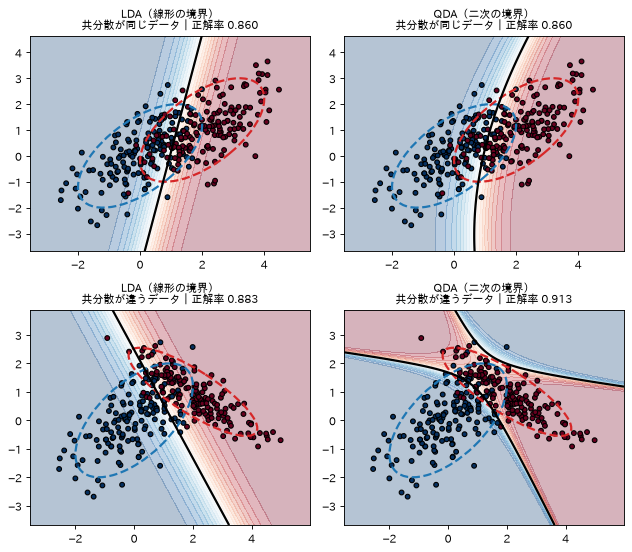

In [2]:
def make_data(same_cov, n=150, seed=0):
    r = np.random.RandomState(seed)
    cov0 = np.array([[1.0, 0.6], [0.6, 1.0]])
    cov1 = cov0 if same_cov else np.array([[1.2, -0.7], [-0.7, 0.6]])
    X0 = r.multivariate_normal([0, 0], cov0, n)
    X1 = r.multivariate_normal([2, 1], cov1, n)
    return np.r_[X0, X1], np.r_[np.zeros(n, int), np.ones(n, int)], (cov0, cov1)

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for row, same in enumerate([True, False]):
    X2, y2, (c0, c1) = make_data(same)
    for col, (name, model) in enumerate([("LDA（線形の境界）", LDA()), ("QDA（二次の境界）", QDA())]):
        model.fit(X2, y2)
        ax = axes[row, col]
        plot_boundary(ax, model, X2, y2, f"{name}\n{'共分散が同じデータ' if same else '共分散が違うデータ'}"
                      f"｜正解率 {model.score(X2, y2):.3f}")
        plot_cov_ellipse(ax, [0, 0], c0, "tab:blue"); plot_cov_ellipse(ax, [2, 1], c1, "tab:red")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **上段（共分散が同じ）**: LDA も QDA も、ほぼ同じ直線に近い境界になります。このようなデータでは、二次の柔軟さは必要ありません。
- **下段（共分散が違う）**: LDA は直線しか引けません。QDA は、赤いクラスの細長い楕円に沿うように**曲がった境界**を引き、正解率も高くなりました。ガイドの図の説明（「LDA は線形の境界しか学習できないが、QDA は二次の境界を学習できるので、より柔軟」）どおりです。

ただし「柔軟なほうが常に良い」わけではありません。どちらを使うべきかは、2 章の実験で確かめます。

### 🧪 やってみよう: 閉形式・多クラス・ハイパーパラメータなし

Iris（アヤメ 3 品種、150 本、特徴 4 個: がく片と花弁の長さと幅）で、何も設定せずに学習してみます。比較のため、1.1 のロジスティック回帰も並べます。

In [3]:
import time
iris = load_iris()
X, y = iris.data, iris.target

rows = {}
for name, model in [("LDA", LDA()), ("QDA", QDA()),
                    ("LogisticRegression", lm.LogisticRegression(max_iter=1000))]:
    t = time.perf_counter()
    model.fit(X, y)
    rows[name] = {"学習時間（ミリ秒）": (time.perf_counter() - t) * 1000, "正解率（学習データ）": model.score(X, y),
                  "classes_": str(model.classes_)}
pd.DataFrame(rows).T

,学習時間（ミリ秒）,正解率（学習データ）,classes_
LDA,1.5009,0.98,[0 1 2]
QDA,0.9111,0.98,[0 1 2]
LogisticRegression,15.7777,0.9733,[0 1 2]


👀 LDA / QDA は、引数なしで 3 クラスをそのまま学習し、ロジスティック回帰と同程度の正解率になりました（ここでは学習データで測っているので、あくまで目安です）。学習時間もごくわずかです。

> ⚠️ **つまずきポイント**: 「ハイパーパラメータがない」とは、**既定のままで使える**という意味です。実際には `solver`・`shrinkage`・`priors` などの引数があり、1.2.4〜1.2.5 で扱うように、データによっては設定したほうが良い場合があります。

---
## 1. LDA による次元削減（1.2.1）

### 📖 ガイドの解説

`LinearDiscriminantAnalysis` は、**教師あり次元削減**にも使えます。入力データを、**クラス間の分離が最大になる方向**からなる**線形部分空間**に射影します（「分離が最大」の正確な意味は 3 章の数式で説明します）。

出力の次元は、必ず**クラス数より小さく**なります。そのため一般にかなり強い次元削減になり、多クラスの場合にしか意味がありません。

この機能は `transform` メソッドで使えます。出力の次元は `n_components` 引数で指定します。**`n_components` は `fit` と `predict` には影響しません。**

> 📚 **用語**
> - **次元削減**: 特徴の数（次元）を減らすこと。4 個の特徴を 2 個にまとめれば、平面にグラフを描けるし、後の計算も軽くなる。
> - **教師あり / 教師なし**: 正解ラベル（ここではクラス）を**使う**のが教師あり、**使わない**のが教師なし。代表的な教師なし次元削減が PCA（主成分分析、2.5 節）。
> - **射影（projection）**: 高い次元の点を、低い次元の直線や平面に「影を落とす」ように写すこと。
> - **線形部分空間**: 原点を通る直線や平面（とその高次元版）。「いくつかの向きの組み合わせで表せる範囲」のこと。

### 💡 補足: PCA との違い — 「広がり」か「分かれ方」か

- **PCA**（教師なし）: データ全体が**いちばん広がっている向き**を探す。クラスのことは知らない。
- **LDA**（教師あり）: **クラスどうしがいちばんよく分かれる向き**を探す。

たとえるなら、集合写真を撮るときに、PCA は「全員がいちばん横に広く写る角度」、LDA は「チームごとにいちばんはっきり分かれて写る角度」を選びます。

出力の次元が「クラス数 − 1」以下になるのは、K 個のクラスの**平均点**が、K − 1 次元の空間に必ず収まるからです（2 点は直線上に、3 点は平面上にある）。クラスを見分けるのに必要な情報は、その空間に全部入っています（3 章で詳しく説明します）。

### 🎯 なぜ使うのか / 🏭 利用例

- **可視化**: 多次元のデータを 2 次元に落として、クラスの分かれ方を目で見る。
- **前処理**: 分類の前に次元を減らし、ノイズや計算量を減らす。顔認識の Fisherfaces は、この使い方の代表例です。

### 🧪 やってみよう: ガイドの例「Iris を LDA と PCA で 2 次元に」

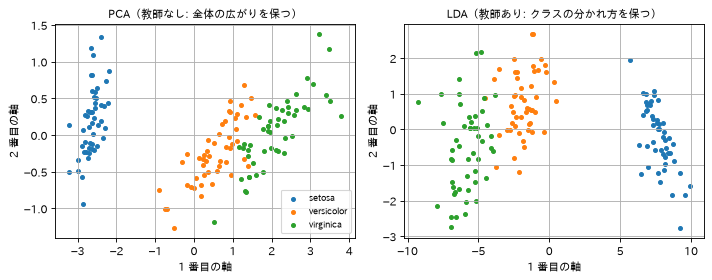

,1 番目の軸だけで分類した正解率,2 番目の軸だけで分類した正解率
PCA,0.9267,0.4533
LDA,0.9800,0.4800


In [4]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X)
X_lda = LDA(n_components=2).fit(X, y).transform(X)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, Z, title in [(axes[0], X_pca, "PCA（教師なし: 全体の広がりを保つ）"),
                     (axes[1], X_lda, "LDA（教師あり: クラスの分かれ方を保つ）")]:
    for k, name in enumerate(iris.target_names):
        ax.scatter(Z[y == k, 0], Z[y == k, 1], s=12, label=name)
    ax.set_title(title, fontsize=10); ax.set_xlabel("1 番目の軸"); ax.set_ylabel("2 番目の軸")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# それぞれの「1 番目の軸」だけを使って分類したら、どれくらい当たるか（5 分割交差検証）
from sklearn.model_selection import cross_val_score
pd.DataFrame({name: {"1 番目の軸だけで分類した正解率": cross_val_score(LDA(), Z[:, :1], y, cv=5).mean(),
                     "2 番目の軸だけで分類した正解率": cross_val_score(LDA(), Z[:, 1:2], y, cv=5).mean()}
              for name, Z in [("PCA", X_pca), ("LDA", X_lda)]}).T

In [5]:
print("LDA の各軸が捉えた「クラス間の違い」の割合:", LDA(n_components=2).fit(X, y).explained_variance_ratio_.round(4))

LDA の各軸が捉えた「クラス間の違い」の割合: [0.9912 0.0088]


### 👀 結果の読み方

- どちらの図でも、setosa（青）は大きく離れています。違いが出るのは、versicolor（オレンジ）と virginica（緑）の境目です。
- 表を見ると、**1 番目の軸だけ**で分類したときの正解率は LDA のほうが高くなっています。LDA の 1 番目の軸は「クラスがいちばんよく分かれる向き」として選ばれているからです。
- **2 番目の軸だけ**では、どちらもほとんど分類の役に立ちません（3 品種を当てずっぽうに選ぶと約 0.33）。
  - LDA の場合は、上の出力のとおり、1 番目の軸が**クラス間の違いの 99% 以上**を捉えていて、2 番目の軸にはほとんど残っていないためです。
  - PCA の場合は、クラスを知らずに「広がりの大きい向き」を選ぶので、2 番目の軸がクラスの区別に役立つとは限りません。

（`cross_val_score` は、データを 5 つに分けて「4 つで学習・1 つで評価」を 5 回繰り返し、平均の正解率を出す関数です。3.1 節で詳しく扱います。）

### 🧪 やってみよう: `n_components` の上限と、`predict` への影響

In [6]:
try:
    LDA(n_components=3).fit(X, y)          # 3 クラスなので上限は 3 - 1 = 2
except ValueError as e:
    print("n_components=3 → ValueError:", e)

a = LDA(n_components=1).fit(X, y)
b = LDA(n_components=2).fit(X, y)
print("transform の出力の形:", a.transform(X).shape, "/", b.transform(X).shape)
print("predict は n_components に関係なく同じ:", (a.predict(X) == b.predict(X)).all())
print("predict_proba も同じ:", np.allclose(a.predict_proba(X), b.predict_proba(X)))

n_components=3 → ValueError: n_components cannot be larger than min(n_features, n_classes - 1).
transform の出力の形: (150, 1) / (150, 2)
predict は n_components に関係なく同じ: True
predict_proba も同じ: True


👀 上限は「特徴数」と「クラス数 − 1」の小さいほうです。`n_components` を変えても、`predict` や `predict_proba` の結果は変わりません。`n_components` は `transform` の出力の次元だけを決めます。

> 🧩 **プログラマ向けの見方**: `LDA` は **Predictor（`predict`）と Transformer（`transform`）の両方の契約**を実装したクラスです。1 つのクラスが複数のインターフェースを実装する例で、TypeScript なら `class LDA implements Classifier, Transformer` に相当します。`n_components` は Transformer 側だけの設定です。

---
## 2. LDA と QDA の分類器の数式（1.2.2）

この章がノートの中心です。確率の基本から順に説明します。

### 📚 用語: 確率の基本

| 用語 | 記号 | 意味 | アヤメの例 |
|---|---|---|---|
| **事前確率** | $P(y = k)$ | データを見る前の、クラス $k$ の割合 | 3 品種が同じ数なら、どれも 1/3 |
| **条件付き確率** | $P(A \mid B)$ | 「B が起きたとき」の A の確率。縦棒 $\mid$ は「〜のとき」と読む | — |
| **尤度（ゆうど）** | $P(x \mid y = k)$ | クラス $k$ だとしたら、この測定値 $x$ がどれくらい出やすいか | setosa なら、花弁の長さ 1.4 cm はよく出る |
| **事後確率** | $P(y = k \mid x)$ | 測定値 $x$ を見た**後**の、クラス $k$ である確率。これが知りたい答え | この花が setosa である確率 |

### 📖 ガイドの解説

LDA と QDA は、どちらも単純な確率モデルから導けます。各クラス $k$ について、データの**クラス条件付き分布** $P(X \mid y = k)$（クラス $k$ のデータがどう分布しているか）をモデル化します。そして、各学習サンプル $x \in \mathbb{R}^d$ について、**ベイズの定理**で予測を求めます。

$$P(y = k \mid x) = \frac{P(x \mid y = k) \, P(y = k)}{P(x)} = \frac{P(x \mid y = k) \, P(y = k)}{\sum_{l} P(x \mid y = l) \cdot P(y = l)}$$

そして、この事後確率が最大になるクラス $k$ を選びます。

### 🔢 数式を読む: ベイズの定理

| 記号 | 意味 |
|---|---|
| $x \in \mathbb{R}^d$ | 1 つのサンプルの特徴（$d$ 個の実数の組）。アヤメなら $d = 4$ |
| $P(y = k \mid x)$ | 知りたい答え: $x$ を見たときクラス $k$ である確率（事後確率） |
| $P(x \mid y = k)$ | クラス $k$ なら $x$ がどれくらい出やすいか（尤度） |
| $P(y = k)$ | クラス $k$ の元々の割合（事前確率） |
| $\sum_l P(x \mid y = l) P(y = l)$ | 分子を全クラスについて足したもの。割ることで、全クラスの確率の合計を 1 にする |

**日本語で読むと**: 「$x$ を見た後でクラス $k$ である確率」は、「クラス $k$ なら $x$ が出やすい度合い」×「クラス $k$ の元々の割合」に比例する。全クラスの分を足して割れば、確率になる。

### 💡 補足: ベイズの定理を身近な例で

ある町で、雨の日は全体の 20%（事前確率）。雨の日に傘を持つ人は 90%、晴れの日でも 10% いる（尤度）。朝、傘を持った人を見かけたとき、今日が雨である確率（事後確率）は？

$$\frac{0.9 \times 0.2}{0.9 \times 0.2 + 0.1 \times 0.8} = \frac{0.18}{0.26} \approx 0.69$$

「傘」という**証拠**を見て、雨の確率が 20% から 69% に**更新**されました。LDA / QDA は、測定値 $x$ を証拠にして、各クラスの確率を更新しているのです。

> 🕰️ **歴史（参考情報）**: ベイズの定理は、18 世紀のイギリスの牧師**トーマス・ベイズ**の遺稿が、友人リチャード・プライスによって 1763 年に発表されたことに由来します。その後、ラプラスが一般的な形に整えました。

### 📖 ガイドの解説（続き）: 多変量正規分布

LDA と QDA では、$P(x \mid y)$ を**多変量正規分布**（多変量ガウス分布）でモデル化します。その確率密度は次の式です（$d$ は特徴の数）。

$$P(x \mid y = k) = \frac{1}{(2\pi)^{d/2} \, |\Sigma_k|^{1/2}} \exp\left( -\frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) \right)$$

### 📚 用語: 多変量正規分布と共分散行列

- **正規分布（ガウス分布）**: 平均のまわりに左右対称に集まり、平均から離れるほど出にくくなる、釣り鐘型の分布。身長や測定誤差などでよく見られる。
- **多変量正規分布**: 正規分布を複数の特徴に広げたもの。2 特徴なら、点は**楕円状**に集まる（上の図の点線の楕円）。
- **平均ベクトル** $\mu_k$: クラス $k$ の各特徴の平均を並べたもの。楕円の**中心**。
- **分散**: 1 つの特徴がどれだけばらつくか。**共分散**: 2 つの特徴が**一緒に**増えたり減ったりする度合い（正なら同じ向き、負なら逆向き）。
- **共分散行列** $\Sigma_k$（シグマ）: 分散と共分散を $d \times d$ の表にまとめたもの。対角に各特徴の分散、それ以外に特徴どうしの共分散が入る。楕円の**形と向き**を決める。
- **行列式** $|\Sigma_k|$: 共分散行列から計算する 1 つの数。楕円の**面積（体積）**に比例し、「全体としてどれくらい広がっているか」を表す。
- **逆行列** $\Sigma_k^{-1}$: 掛けると単位行列（何もしない行列）になる行列。数で言えば「割り算」に当たる。
- **転置** $^T$: 縦のベクトルを横にする（行と列を入れ替える）操作。$a^T b$ は 2 つのベクトルの内積（要素ごとの積の和）。

### 🔢 数式を読む: 多変量正規分布の密度

式を 3 つの部分に分けます。

1. $(x - \mu_k)$: 点 $x$ が、クラスの中心 $\mu_k$ から**どれだけずれているか**（ベクトル）。
2. $(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)$: そのずれを、クラスの**広がり方で割った**「ずれの大きさ」（1 つの数）。広がりの大きい向きのずれは小さく数え、狭い向きのずれは大きく数える。これが後で出てくる**マハラノビス距離**（の二乗）です。
3. $\exp(-\frac{1}{2} \times \text{ずれの大きさ})$: ずれが 0 なら 1、ずれが大きいほど急速に 0 に近づく。**中心に近いほど出やすい**。
4. 先頭の $\frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}}$: 全体の確率の合計が 1 になるようにする調整の係数。**広がった分布ほど（$|\Sigma_k|$ が大きいほど）、1 点あたりの密度は低くなる**。

**日本語で読むと**: 「クラス $k$ の中心から、広がり方を考慮してどれだけ離れているか」で出やすさが決まり、離れるほど指数的に出にくくなる。

### 🧪 やってみよう: ベイズの定理と多変量正規分布を手で計算して、QDA と照合する

QDA が学習した平均 `means_`・共分散 `covariance_`・事前確率 `priors_` を使い、上の 2 つの式で事後確率を手計算します。`store_covariance=True` を指定すると、学習した共分散行列が保存されます。

In [7]:
from scipy.stats import multivariate_normal

qda = QDA(store_covariance=True).fit(X, y)
print("事前確率 priors_:", qda.priors_)
print("setosa の平均ベクトル means_[0]:", qda.means_[0])

# 尤度 P(x | y=k) × 事前確率 P(y=k) をクラスごとに計算
joint = np.column_stack([multivariate_normal(qda.means_[k], qda.covariance_[k]).pdf(X) * qda.priors_[k]
                         for k in range(3)])
posterior = joint / joint.sum(axis=1, keepdims=True)     # ベイズの定理: 全クラスの和で割る

print("手計算の事後確率と predict_proba が一致:", np.allclose(posterior, qda.predict_proba(X)))
print("事後確率が最大のクラスと predict が一致:", (posterior.argmax(axis=1) == qda.predict(X)).all())
print("\n51 番目の花（versicolor）の事後確率:", posterior[50].round(4))

事前確率 priors_: [0.3333 0.3333 0.3333]
setosa の平均ベクトル means_[0]: [5.006 3.428 1.462 0.246]
手計算の事後確率と predict_proba が一致: True
事後確率が最大のクラスと predict が一致: True

51 番目の花（versicolor）の事後確率: [0. 1. 0.]


👀 QDA の中身は、本当に「多変量正規分布の尤度 × 事前確率 → 合計で割る → 最大のクラスを選ぶ」だけでした。

### 1.2.2.1 QDA

📖 上のモデルに従うと、事後確率の**対数**は次のようになります。

$$\begin{aligned}
\log P(y = k \mid x) &= \log P(x \mid y = k) + \log P(y = k) + Cst \\
&= -\frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log P(y = k) + Cst
\end{aligned}$$

定数項 $Cst$ には、分母の $P(x)$ と、正規分布の式に出てくるほかの定数が含まれます。予測されるクラスは、この**対数事後確率**を最大にするクラスです。

### 🔢 数式を読む: QDA の対数事後確率

💡 **なぜ対数を取るのか**: 掛け算が足し算になり、$\exp$ も消えるので、式が読みやすく計算も安定します。対数は単調に増える関数なので、「確率が最大のクラス」と「対数確率が最大のクラス」は同じです。

| 項 | 意味 | 大きくなる（そのクラスに決まりやすい）のは |
|---|---|---|
| $-\frac{1}{2} \log \lvert\Sigma_k\rvert$ | 広がりの罰 | クラス $k$ がコンパクトにまとまっているとき |
| $-\frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)$ | ずれの罰 | $x$ がクラス $k$ の中心に（広がりを考慮して）近いとき |
| $\log P(y = k)$ | 事前確率のボーナス | クラス $k$ が元々多いとき |
| $Cst$ | どのクラスでも同じ値 | —（比較には影響しない） |

**日本語で読むと**: 「中心に近く、まとまったクラスで、元々多いクラス」ほど選ばれやすい。

💡 **なぜ境界が二次（曲線）になるのか**: ずれの罰の項は $x$ について**二次式**（$x$ と $x$ の掛け算を含む）です。クラスごとに $\Sigma_k$ が違うので、2 つのクラスの点数を引き算しても二次の項が消えず、境界は曲線になります。

### 📖 ノート: ガウシアン・ナイーブベイズとの関係

QDA のモデルで、共分散行列が**対角行列**だと仮定すると、入力は各クラスの中で**条件付き独立**と仮定したことになります。その結果の分類器は、**ガウシアン・ナイーブベイズ**（`naive_bayes.GaussianNB`、1.9 節）と同じになります。

> 📚 **用語**
> - **対角行列**: 対角（左上から右下）以外がすべて 0 の行列。共分散行列が対角なら、「特徴どうしの共分散は 0」、つまり楕円が軸に沿った向きになる。
> - **条件付き独立**: 「クラスが分かれば、ある特徴の値を知っても、ほかの特徴の予想は変わらない」という仮定。現実には成り立たないことも多いが、推定するパラメータが大幅に減る。

### 🧪 やってみよう: GaussianNB は「対角共分散の QDA」か

In [8]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB(var_smoothing=0).fit(X, y)       # var_smoothing=0: 分散に小さな値を足す安定化を切る

# 共分散行列を「対角（各特徴の分散だけ）」にした多変量正規分布で、ベイズの定理を計算
joint_diag = np.column_stack([multivariate_normal(gnb.theta_[k], np.diag(gnb.var_[k])).pdf(X) * gnb.class_prior_[k]
                              for k in range(3)])
print("対角共分散の事後確率と GaussianNB.predict_proba が一致:",
      np.allclose(joint_diag / joint_diag.sum(axis=1, keepdims=True), gnb.predict_proba(X)))
print("正解率  QDA:", round(qda.score(X, y), 3), "/ GaussianNB:", round(gnb.score(X, y), 3))

対角共分散の事後確率と GaussianNB.predict_proba が一致: True
正解率  QDA: 0.98 / GaussianNB: 0.96


👀 一致しました。GaussianNB は「特徴どうしの相関を無視した QDA」です。アヤメでは花弁の長さと幅が強く相関しているので、相関まで扱える QDA のほうが少し正解率が高くなっています。

### 1.2.2.2 LDA

📖 LDA は QDA の特殊ケースで、各クラスのガウス分布が**同じ共分散行列を共有する**と仮定します。すべての $k$ について $\Sigma_k = \Sigma$ です。すると、対数事後確率は次のように簡単になります。

$$\log P(y = k \mid x) = -\frac{1}{2} (x - \mu_k)^T \Sigma^{-1} (x - \mu_k) + \log P(y = k) + Cst$$

（$-\frac{1}{2}\log|\Sigma|$ は全クラスで同じになったので、$Cst$ に含まれました。）

$(x - \mu_k)^T \Sigma^{-1} (x - \mu_k)$ の項は、サンプル $x$ と平均 $\mu_k$ の間の**マハラノビス距離**（の二乗）に当たります。マハラノビス距離は、各特徴の分散も考慮したうえで、$x$ が $\mu_k$ にどれだけ近いかを表します。したがって LDA は、「**事前確率も考慮しつつ、マハラノビス距離でいちばん近い平均を持つクラスに $x$ を割り当てる**」と解釈できます。

### 📚 用語: マハラノビス距離

普通の距離（**ユークリッド距離**）は、定規で測ったまっすぐな距離です。マハラノビス距離は、**データの広がり方で目盛りを変えた**距離です。

💡 **たとえ**: 身長と体重の 2 つで人を比べるとき、「身長 10 cm の差」と「体重 10 kg の差」は同じ重みではありません。さらに身長と体重は一緒に増える傾向があるので、「背が高くて重い」は珍しくないが、「背が低くて重い」は珍しい。マハラノビス距離は、**ばらつきの大きい向きのずれは小さく、珍しい向きのずれは大きく**数えます。

### 🧪 やってみよう: ユークリッド距離とマハラノビス距離の違いを見る

斜めに広がったデータで、中心から「ユークリッド距離が同じ 2 点」をとり、マハラノビス距離を比べます。

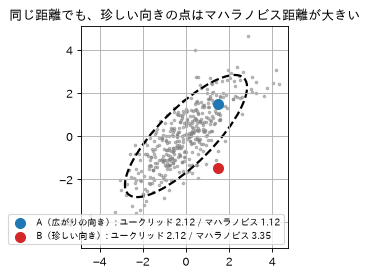

In [9]:
rng = np.random.RandomState(1)
cov = np.array([[2.0, 1.6], [1.6, 2.0]])            # 右上がりに斜めに広がる
pts = rng.multivariate_normal([0, 0], cov, 400)
inv = np.linalg.inv(cov)
A, B = np.array([1.5, 1.5]), np.array([1.5, -1.5])   # 原点からのユークリッド距離はどちらも約 2.12

def mahalanobis(p):
    return np.sqrt(p @ inv @ p)

plt.scatter(pts[:, 0], pts[:, 1], s=5, c="gray", alpha=0.5)
plot_cov_ellipse(plt.gca(), [0, 0], cov, "black")
for p, name, c in [(A, "A（広がりの向き）", "tab:blue"), (B, "B（珍しい向き）", "tab:red")]:
    plt.scatter(*p, s=80, c=c, zorder=3,
                label=f"{name}: ユークリッド {np.linalg.norm(p):.2f} / マハラノビス {mahalanobis(p):.2f}")
plt.gca().set_aspect("equal"); plt.legend(fontsize=8, loc="lower right")
plt.title("同じ距離でも、珍しい向きの点はマハラノビス距離が大きい"); plt.show()

👀 A と B は、原点からの普通の距離は同じです。しかし、データが広がっている向きにある A はマハラノビス距離が小さく（ありふれた点）、データがほとんどない向きにある B は大きくなります（珍しい点）。LDA はこの「珍しさ」で、どのクラスに近いかを判断しています。

> 🕰️ **歴史（参考情報）**: マハラノビス距離は、インド統計研究所の創設者 **P. C. マハラノビス**が 1936 年の論文 *On the generalised distance in statistics* で発表しました。もともとは、人類学の調査で集団どうしの違いを測るために考えられたものです。

### 📖 ガイドの解説（続き）: LDA は線形

LDA の対数事後確率は、次のようにも書けます。

$$\log P(y = k \mid x) = \omega_k^T x + \omega_{k0} + Cst$$

ここで $\omega_k = \Sigma^{-1} \mu_k$、$\omega_{k0} = -\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log P(y = k)$ です。これらは、それぞれ `coef_` と `intercept_` 属性に当たります。

この式から、LDA の決定境界が**線形**であることが分かります。QDA では各ガウス分布の共分散行列 $\Sigma_k$ に仮定を置かないので、決定境界は二次になります。

### 🔢 数式を読む: なぜ LDA は線形になるのか

ずれの罰を展開すると、次の 3 つの項になります。

$$(x - \mu_k)^T \Sigma^{-1} (x - \mu_k) = \underbrace{x^T \Sigma^{-1} x}_{\text{全クラス共通}} - 2 \mu_k^T \Sigma^{-1} x + \mu_k^T \Sigma^{-1} \mu_k$$

$\Sigma$ が全クラスで同じなので、**二次の項 $x^T \Sigma^{-1} x$ は全クラスで同じ値**になり、比較のときに消えます（$Cst$ に入る）。残るのは $x$ の一次の項だけです。

| 記号 | 意味 | scikit-learn の属性 |
|---|---|---|
| $\omega_k = \Sigma^{-1} \mu_k$ | クラス $k$ の「重み」。平均を広がり方で補正したもの | `coef_[k]` |
| $\omega_{k0}$ | クラス $k$ の「基本点」。平均が遠いほど減り、元々多いほど増える | `intercept_[k]` |

**日本語で読むと**: LDA は、各クラスについて「重み × 特徴 + 基本点」という**1.1 と同じ形の線形のスコア**を計算し、いちばん高いクラスを選んでいる。

### 🧪 やってみよう: `coef_` と `intercept_` を式どおりに計算する

In [10]:
lda = LDA(solver="lsqr", store_covariance=True).fit(X, y)
Sigma = lda.covariance_                                   # 全クラス共通の共分散行列
W = np.linalg.solve(Sigma, lda.means_.T).T                # ω_k = Σ^{-1} μ_k（逆行列を作らずに解く）
w0 = -0.5 * np.sum(lda.means_ * W, axis=1) + np.log(lda.priors_)

print("coef_ = Σ^{-1} μ_k と一致:", np.allclose(W, lda.coef_))
print("intercept_ = -1/2 μ_k^T Σ^{-1} μ_k + log P(y=k) と一致:", np.allclose(w0, lda.intercept_))

# マハラノビス距離で一番近い平均（+ 事前確率）を選ぶと、predict と同じになるか
d2 = np.column_stack([np.einsum("ij,jk,ik->i", X - m, np.linalg.inv(Sigma), X - m) for m in lda.means_])
print("「マハラノビス距離² / 2 − log 事前確率」が最小のクラス == predict:",
      ((0.5 * d2 - np.log(lda.priors_)).argmin(axis=1) == lda.predict(X)).all())

coef_ = Σ^{-1} μ_k と一致: True
intercept_ = -1/2 μ_k^T Σ^{-1} μ_k + log P(y=k) と一致: True
「マハラノビス距離² / 2 − log 事前確率」が最小のクラス == predict: True


👀 3 つとも一致しました。LDA の予測は「マハラノビス距離でいちばん近いクラスの平均を選ぶ」ことと同じで、それは「線形のスコアが最大のクラスを選ぶ」ことと同じです。

### ⚠️ つまずきポイント（ガイドに書かれていない）: `coef_` の値はソルバによって変わる

既定の `solver="svd"` と `solver="lsqr"` で `coef_` を比べます。

In [11]:
svd = LDA(solver="svd").fit(X, y)
print("coef_ が一致:", np.allclose(svd.coef_, lda.coef_))
print("predict_proba は一致:", np.allclose(svd.predict_proba(X), lda.predict_proba(X)))
print("coef_ の差（svd − lsqr）:\n", (svd.coef_ - lda.coef_).round(3))

coef_ が一致: False
predict_proba は一致: True
coef_ の差（svd − lsqr）:
 [[-17.581 -11.682  -0.526  -3.44 ]
 [-17.581 -11.682  -0.526  -3.44 ]
 [-17.581 -11.682  -0.526  -3.44 ]]


👀 確率も予測も同じなのに、`coef_` の値は違います。差を見ると、**3 クラスとも同じベクトル**がずれています。全クラスのスコアに同じ量を足しても、どのクラスが最大かは変わらず、確率（ソフトマックス、1.1 の 3/4 参照）も変わりません。つまり多クラスの `coef_` は一意に決まらず、**意味があるのはクラス間の差**だけです。`coef_` を「特徴の重要度」として読むときは注意してください。

### 🧪 やってみよう: LDA と QDA、どちらを使うべきか

QDA はクラスごとに共分散行列を推定するので、推定する数が LDA のクラス数倍になります。特徴が 5 個なら、共分散行列 1 つにつき 15 個（5 個の分散 + 10 個の共分散）の値を推定します。**データが少ないと、この推定がぶれます**。

共分散が「同じ」データと「違う」データで、1 クラスあたりのサンプル数を変えて、テストの正解率（30 回の平均）を比べます。`reg_param` は QDA の共分散行列を単位行列の方向へ縮める引数で、ガイドの本文では触れられていませんが、少ないデータで QDA を安定させるのに使えます。

In [12]:
def make_5d(n_per_class, same_cov, r):
    cov1 = np.eye(5) if same_cov else np.diag([4.0, 0.25, 1, 1, 1])
    X0 = r.multivariate_normal(np.zeros(5), np.eye(5), n_per_class)
    X1 = r.multivariate_normal([1.5, 0, 0, 0, 0], cov1, n_per_class)
    return np.r_[X0, X1], np.r_[np.zeros(n_per_class), np.ones(n_per_class)]

rows = []
for same in [True, False]:
    for n_k in [8, 15, 50, 500]:
        r = np.random.RandomState(0)
        acc = {"LDA": [], "QDA": [], "QDA(reg_param=0.5)": []}
        for _ in range(30):
            Xtr, ytr = make_5d(n_k, same, r); Xte, yte = make_5d(1000, same, r)
            acc["LDA"].append(LDA().fit(Xtr, ytr).score(Xte, yte))
            acc["QDA"].append(QDA().fit(Xtr, ytr).score(Xte, yte))
            acc["QDA(reg_param=0.5)"].append(QDA(reg_param=0.5).fit(Xtr, ytr).score(Xte, yte))
        rows.append({"データ": "共分散が同じ" if same else "共分散が違う", "1 クラスのサンプル数": n_k,
                     **{k: np.mean(v) for k, v in acc.items()}})
pd.DataFrame(rows).set_index(["データ", "1 クラスのサンプル数"])

LDA     QDA  QDA(reg_param=0.5)
データ    1 クラスのサンプル数                                    
共分散が同じ 8            0.6879  0.6036              0.7047
       15           0.7275  0.6771              0.7284
       50           0.7640  0.7402              0.7619
       500          0.7729  0.7694              0.7726
共分散が違う 8            0.6112  0.6178              0.6722
       15           0.6408  0.6753              0.6876
       50           0.6835  0.7293              0.7246
       500          0.7041  0.7533              0.7368

### 👀 結果の読み方

- **共分散が同じデータ**: LDA はどのサンプル数でも QDA 以上です。QDA は、サンプルが少ないと余計な違い（ノイズ）まで学習してしまい、正解率が下がります（**過学習**）。
- **共分散が違うデータ**: サンプルが少ないうちは差が小さいですが、サンプルが増えると QDA が LDA をはっきり上回ります。LDA は「共分散が同じ」という**間違った仮定**に縛られ、データが増えても改善が頭打ちになります。
- `reg_param` を入れた QDA は、サンプルが少ないときに素の QDA より良くなりました。

💡 これは、機械学習でよく出てくる**バイアスとバリアンスのトレードオフ**の典型例です。

> 📚 **用語**
> - **バイアス**: モデルの仮定が単純すぎることによる、系統的なずれ（LDA が曲線を表せないこと）。
> - **バリアンス**: データの偶然の違いに振り回されることによる、推定のぶれ（少ないデータで QDA の共分散がぶれること）。
>
> 仮定の強いモデル（LDA）はバイアスが大きくバリアンスが小さく、柔軟なモデル（QDA）はその逆です。**データが少なければ LDA、多くてクラスごとの形が違うなら QDA** が目安です。

---
## 3. LDA による次元削減の数式（1.2.3）

### 📖 ガイドの解説

まず、K 個のクラスの平均 $\mu_k$ は $\mathbb{R}^d$ のベクトルで、これらは次元が**最大 K − 1** の**アフィン部分空間** $H$ に含まれます（2 点は直線上に、3 点は平面上にある、など）。

前の章で見たように、LDA は「事前確率も考慮しつつ、マハラノビス距離でいちばん近い平均 $\mu_k$ のクラスに $x$ を割り当てる」と解釈できます。別の見方をすると、LDA は次の手順と同じです。

1. まずデータを**球面化**して、共分散行列が単位行列になるようにする
2. そのうえで、（事前確率も考慮しつつ）**ユークリッド距離**でいちばん近い平均のクラスに $x$ を割り当てる

この $d$ 次元の空間でユークリッド距離を計算するのは、データ点をまず $H$ に射影してから、そこで距離を計算するのと同じです（ほかの次元は、距離に対して全クラスに同じだけ寄与するからです）。つまり、元の空間で $x$ が $\mu_k$ に最も近ければ、$H$ の中でもそうです。

このことから、LDA 分類器の中には、**K − 1 次元の空間への線形射影による次元削減**が暗に含まれていることが分かります。

さらに、選んだ次元 $L$ まで次元を減らすこともできます。射影後の変換済みクラス平均 $\mu^*_k$ の分散が最大になる線形部分空間 $H_L$ に射影するのです（実質的には、変換後のクラス平均 $\mu^*_k$ に対して PCA を行っていることになります）。この $L$ が、`transform` メソッドで使う `n_components` 引数に当たります。

> 📚 **用語**
> - **アフィン部分空間**: 原点を通るとは限らない直線や平面（とその高次元版）。「線形部分空間を平行移動したもの」。
> - **球面化（sphering）/ 白色化（whitening）**: データを変換して、どの向きにも同じだけ広がり、特徴どうしの相関もない状態（共分散行列 = 単位行列）にすること。楕円に広がったデータを、まん丸に整えるイメージ。
> - **単位行列**: 対角がすべて 1、それ以外が 0 の行列。「何もしない」行列で、共分散行列がこれなら、各特徴の分散が 1 で相関がない。

### 💡 補足: 3 ステップで考える

1. **球面化**: クラスの楕円をまん丸にする。すると、マハラノビス距離が普通の定規の距離（ユークリッド距離）になる。
2. **平均が乗る面に射影**: 3 クラスなら 3 つの平均が乗る平面だけを見れば十分。その平面に垂直な向きのずれは、どのクラスの平均からも同じだけなので、判定に影響しない。
3. **さらに減らす**（任意）: その平面の中で、平均どうしがいちばん離れて見える向きだけを残す。

1.2.1 の図で、Iris の 3 品種が 2 次元（= 3 − 1）にきれいに収まったのは、このためです。

### 🧪 やってみよう: `transform` 後の空間で確かめる

(1) 変換後のデータは、クラス内の共分散がほぼ単位行列（球面化されている）か、(2) 変換後の空間で「ユークリッド距離でいちばん近い平均（+ 事前確率）」を選ぶと、`predict` と一致するか、を確かめます。

In [13]:
lda2 = LDA(n_components=2).fit(X, y)
Z = lda2.transform(X)
centers = np.array([Z[y == k].mean(axis=0) for k in range(3)])

within = Z - centers[y]                                   # 各点から自分のクラスの平均を引く
print("変換後のクラス内共分散（単位行列に近ければ球面化されている）:\n",
      np.cov(within.T, ddof=3).round(3))                  # ddof=3: クラス数分の自由度を引く

score = 0.5 * ((Z[:, None, :] - centers[None]) ** 2).sum(axis=2) - np.log(lda2.priors_)
print("変換後の空間で「ユークリッド距離² / 2 − log 事前確率」が最小のクラス == predict:",
      (score.argmin(axis=1) == lda2.predict(X)).all())

変換後のクラス内共分散（単位行列に近ければ球面化されている）:
 [[1.02 0.  ]
 [0.   1.02]]
変換後の空間で「ユークリッド距離² / 2 − log 事前確率」が最小のクラス == predict: True


👀 変換後のクラス内共分散はほぼ単位行列で、変換後の空間での最近傍の判定も `predict` と完全に一致しました。「LDA の分類には、K − 1 次元への射影が暗に含まれている」というガイドの説明を、実際に確かめられました。

---
## 4. 縮小推定と共分散の推定器（1.2.4 Shrinkage and Covariance Estimator）

### 📖 ガイドの解説

**縮小推定（shrinkage）**は正則化の一種で、**学習サンプルの数が特徴の数に比べて少ない**状況で、共分散行列の推定を改善するために使います。このような状況では、**経験的な標本共分散**は推定量として性能が悪く、縮小推定を使うと分類器の**汎化性能**が上がります。

LDA（または QDA）で縮小推定を使うには、`shrinkage` 引数を `'auto'` にします。すると、Ledoit と Wolf が導いた補題に従い、最適な縮小パラメータが解析的に自動で決まります。ただし現在、縮小推定は `solver` が `'lsqr'` か `'eigen'` のときだけ使えます（QDA は `'eigen'` のみ）。

縮小パラメータは、0 から 1 の間で手動でも指定できます。

- **0**: 縮小なし（経験的な共分散行列をそのまま使う）
- **1**: 完全な縮小（各特徴の分散だけを並べた**対角行列**を共分散行列の推定値にする）
- その間の値: 縮小した共分散行列を推定する

> 📚 **用語**
> - **経験的な標本共分散（empirical covariance）**: 手元のデータから、定義どおりにそのまま計算した共分散行列。
> - **汎化性能**: 学習に使っていない新しいデータに対する性能。
> - **正則化**: 推定が極端な値にならないように、単純な方向へ引き寄せること（1.1 の Ridge と同じ考え方）。

### 🎯 なぜ使うのか

特徴が $d$ 個あると、共分散行列には $d(d+1)/2$ 個の値があります。特徴 75 個なら 2850 個です。それを 20 件のサンプルから推定するのは無理があります。特に**サンプル数が特徴数より少ない**と、経験的な共分散行列は**逆行列が作れない**（特異になる）ので、LDA の式 $\Sigma^{-1}$ がそのままでは計算できません。

縮小推定は、「経験的な共分散」と「単純な対角行列」の**中間**をとります。

$$\hat{\Sigma}_\text{shrunk} = (1 - s) \, \hat{\Sigma}_\text{経験的} + s \, \operatorname{diag}(\hat{\Sigma}_\text{経験的})$$

（$s$ が縮小パラメータ。scikit-learn の実装は内部で特徴のスケールをそろえてから縮小しますが、考え方はこの式のとおりです。）

### 🔢 数式を読む

- $s = 0$: 手元のデータを全面的に信じる（ばらつきが大きい）
- $s = 1$: 「特徴どうしは相関しない」という単純な仮定を全面的に信じる（偏りが大きい）
- その間: 両方を混ぜて、**バイアスとバリアンスのちょうど良い妥協点**を探す。2 章の LDA と QDA の関係と同じトレードオフです。

### 🕰️ 歴史（参考情報）

- **Ledoit–Wolf 推定量**: オリヴィエ・ルドワとマイケル・ウルフが、2004 年の論文 *Honey, I Shrunk the Sample Covariance Matrix*（The Journal of Portfolio Management, 30(4)）で広めました。もともとは**金融のポートフォリオ最適化**のために考えられたものです。数百の銘柄の共分散を、限られた期間の株価データから推定しなければならない、まさに「サンプルが少なく特徴が多い」問題でした。最適な混ぜ具合 $s$ を、データから**解析的に**（数式 1 本で）求められるのが特徴です。
- **OAS（Oracle Approximating Shrinkage）**: Chen・Wiesel・Eldar・Hero が 2010 年に IEEE Transactions on Signal Processing で発表した推定量で、データが正規分布に従うときに Ledoit–Wolf より誤差が小さくなるように設計されています。

### 🏭 利用例

- 脳波（EEG）の分類: 数十チャンネル × 時間の特徴に対して、1 人あたりの試行回数（サンプル）は少ないことが多く、縮小推定付きの LDA が標準的な手法になっています。
- 遺伝子発現データ: 数千の遺伝子（特徴）に対し、患者（サンプル）は数十人ということがよくあります。

### 🧪 やってみよう: サンプル数 < 特徴数だと、共分散行列はどうなるか

In [14]:
r = np.random.RandomState(0)
X_small = r.randn(20, 50)                                 # サンプル 20 件、特徴 50 個
emp = np.cov(X_small.T)
print("共分散行列の大きさ:", emp.shape, "/ ランク（独立な向きの数）:", np.linalg.matrix_rank(emp))
print("最小固有値:", np.linalg.eigvalsh(emp).min().round(6), "→ 0 なので逆行列が作れない")

lda_s1 = LDA(solver="lsqr", shrinkage=1.0, store_covariance=True).fit(X, y)
off = lda_s1.covariance_ - np.diag(np.diag(lda_s1.covariance_))
print("\nshrinkage=1.0 の共分散行列の、対角以外の最大値:", np.abs(off).max(), "→ 対角行列になっている")

共分散行列の大きさ: (50, 50) / ランク（独立な向きの数）: 19
最小固有値: -0.0 → 0 なので逆行列が作れない

shrinkage=1.0 の共分散行列の、対角以外の最大値: 0.0 → 対角行列になっている


👀 20 件のデータからは、50 × 50 の共分散行列のうち最大 19 個の向き（ランク 19）しか分かりません。残りの向きは「ばらつき 0」と推定され、逆行列が作れません。また、`shrinkage=1.0` にすると、ガイドの説明どおり共分散行列が対角行列（特徴どうしの共分散がすべて 0）になりました。

### 📖 ガイドの解説（続き）: 共分散の推定器を選ぶ

Ledoit–Wolf の縮小推定量（`shrinkage="auto"`）が、常に最善とは限りません。たとえばデータが正規分布に従う場合は、**Oracle Approximating Shrinkage** 推定量 `sklearn.covariance.OAS` のほうが、Ledoit–Wolf の式より平均二乗誤差が小さくなります。LDA と QDA は、データがクラスごとに正規分布に従うと仮定しています。その仮定が成り立つなら、OAS 推定量を使った LDA / QDA のほうが、Ledoit–Wolf や経験的な共分散を使うより良い分類精度になります。

共分散の推定器は、`LinearDiscriminantAnalysis` と `QuadraticDiscriminantAnalysis` の `covariance_estimator` 引数で選べます。推定器は、`sklearn.covariance` モジュールのすべての共分散推定器と同じく、`fit` メソッドと `covariance_` 属性を持っている必要があります。

### 🧪 やってみよう: ガイドの例「Normal, Ledoit-Wolf and OAS LDA」を再現する

ガイドの例と同じ設定です。本当にクラスを見分けるのに役立つ特徴は 1 つだけで、残りはすべてノイズの特徴です。学習データは 20 件だけで、特徴の数を増やしていきます（テスト 200 件、50 回の平均）。

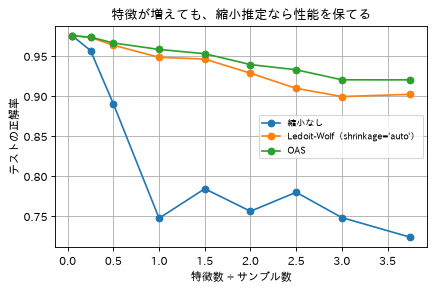

特徴数,1,5,10,20,30,40,50,60,75
縮小なし,0.9753,0.9567,0.8902,0.7473,0.7841,0.7560,0.7797,0.7481,0.7235
Ledoit-Wolf（shrinkage='auto'）,0.9753,0.9731,0.9634,0.9483,0.9461,0.9284,0.9095,0.8993,0.9020
OAS,0.9753,0.9735,0.9662,0.9581,0.9528,0.9392,0.9327,0.9202,0.9201


In [15]:
from sklearn.covariance import OAS
from sklearn.datasets import make_blobs

def generate(n, n_features, r):
    Xg, yg = make_blobs(n_samples=n, n_features=1, centers=[[-2], [2]], random_state=r)
    if n_features > 1:
        Xg = np.hstack([Xg, r.randn(n, n_features - 1)])     # 残りはノイズの特徴
    return Xg, yg

feature_counts = [1, 5, 10, 20, 30, 40, 50, 60, 75]
curves = {"縮小なし": [], "Ledoit-Wolf（shrinkage='auto'）": [], "OAS": []}
r = np.random.RandomState(0)
for p in feature_counts:
    acc = {k: [] for k in curves}
    for _ in range(50):
        Xtr, ytr = generate(20, p, r); Xte, yte = generate(200, p, r)
        acc["縮小なし"].append(LDA(solver="lsqr").fit(Xtr, ytr).score(Xte, yte))
        acc["Ledoit-Wolf（shrinkage='auto'）"].append(LDA(solver="lsqr", shrinkage="auto").fit(Xtr, ytr).score(Xte, yte))
        acc["OAS"].append(LDA(solver="lsqr", covariance_estimator=OAS()).fit(Xtr, ytr).score(Xte, yte))
    for k in curves:
        curves[k].append(np.mean(acc[k]))

for k, v in curves.items():
    plt.plot(np.array(feature_counts) / 20, v, marker="o", label=k)
plt.xlabel("特徴数 ÷ サンプル数"); plt.ylabel("テストの正解率")
plt.legend(fontsize=8); plt.title("特徴が増えても、縮小推定なら性能を保てる"); plt.show()
pd.DataFrame(curves, index=pd.Index(feature_counts, name="特徴数")).T

### 👀 結果の読み方

- **縮小なし**: 特徴が増えると正解率が大きく下がります。ノイズの特徴どうしの「見かけの相関」を本物だと思い込み、共分散行列の推定が壊れるためです。
- **Ledoit–Wolf** と **OAS**: 特徴数がサンプル数の 3 倍を超えても、高い正解率を保っています。
- このデータは正規分布から作っているので、ガイドの説明どおり **OAS が Ledoit–Wolf をやや上回りました**。

> ⚠️ **つまずきポイント**: `shrinkage` や `covariance_estimator` は、既定の `solver="svd"` では使えません。`solver="lsqr"`（または `"eigen"`）を一緒に指定する必要があります（次の章で確かめます）。

---
## 5. 推定アルゴリズム（1.2.5 Estimation algorithms）

### 📖 ガイドの解説

LDA と QDA を使うには、対数事後確率を計算する必要があります。それには、クラスの事前確率 $P(y = k)$、クラスの平均 $\mu_k$、共分散行列が必要です。

**`'svd'` ソルバ**（既定）

- `LinearDiscriminantAnalysis` と `QuadraticDiscriminantAnalysis` の既定のソルバ。
- 分類と `transform`（LDA の場合）の両方ができる。
- 共分散行列を計算しないので、**特徴の数が多い**場合に向いていることがある。
- **縮小推定とは一緒に使えない。**
- QDA の場合: 共分散行列は定義から $\Sigma_k = \frac{1}{n} X_k^T X_k = \frac{1}{n} V S^2 V^T$ と書けます（$V$ は中心化したクラス $k$ のデータ行列の SVD $X_k = U S V^T$ から得られる）。そのため、$\Sigma$ を明示的に計算しなくても、$X$ の SVD で $S$ と $V$ を求めれば、対数事後確率を計算できます。
- LDA の場合: 中心化した入力行列 $X$ の SVD と、クラスごとの平均ベクトルの SVD の 2 つを計算します。

**`'lsqr'` ソルバ**

- **分類専用**の効率的なアルゴリズム（`transform` は使えない）。
- 共分散行列 $\Sigma$ を明示的に計算する必要があり、縮小推定と独自の共分散推定器に対応する。
- 係数 $\omega_k = \Sigma^{-1} \mu_k$ を、連立方程式 $\Sigma \omega = \mu_k$ を解いて求める。逆行列 $\Sigma^{-1}$ を明示的に計算しないで済む。

**`'eigen'` ソルバ**

- LDA の場合: **クラス間散布とクラス内散布の比**の最適化に基づく。分類にも `transform` にも使え、縮小推定に対応する。
- QDA の場合: 各クラスの共分散行列の固有値と固有ベクトルを計算する。分類で縮小推定が使える。
- ただし共分散行列を計算する必要があるので、特徴の数が多い場合には向かないことがある。

> 📚 **用語**
> - **SVD（特異値分解）**: 行列を $U S V^T$ という 3 つの行列の積に分解する方法。$V$ はデータが広がる向き、$S$ はその向きの広がりの大きさを表す。共分散行列を作らずに、データ行列から直接「広がりの向きと大きさ」が分かる。
> - **固有値・固有ベクトル**: 共分散行列の固有ベクトルは楕円の軸の向き、固有値はその軸の長さ（分散）を表す。
> - **中心化**: 各特徴から平均を引いて、平均を 0 にすること。
> - **クラス間散布 / クラス内散布**: クラスの平均どうしがどれだけ離れているか / 各クラスの中でデータがどれだけばらついているか。フィッシャーの元の考え方は、この**比を最大にする向き**を探すことでした（歴史の節を参照）。
> - **連立方程式を解く vs 逆行列を作る**: $\Sigma^{-1} \mu$ を求めるのに、逆行列を作ってから掛けるより、$\Sigma \omega = \mu$ を直接解くほうが速く、数値誤差も小さい。1.2.2.2 のコードで `np.linalg.solve` を使ったのもこのためです。

### ソルバの比較表

| ソルバ | 分類 | `transform` | 縮小推定・`covariance_estimator` | 共分散行列を作る | 向いている場面 |
|---|---|---|---|---|---|
| `svd`（既定） | ✅ | ✅ | — | 作らない | 特徴が多い |
| `lsqr` | ✅ | — | ✅ | 作る | 分類だけ、縮小推定を使いたい |
| `eigen` | ✅ | ✅ | ✅ | 作る | 次元削減 + 縮小推定 |

### 🧪 やってみよう: 表の「—」を確かめる

In [16]:
for label, make in [("svd + shrinkage", lambda: LDA(solver="svd", shrinkage="auto").fit(X, y)),
                    ("lsqr + transform", lambda: LDA(solver="lsqr").fit(X, y).transform(X))]:
    try:
        make(); print(f"{label}: 動いた")
    except NotImplementedError as e:
        print(f"{label}: NotImplementedError — {e}")

eig = LDA(solver="eigen", shrinkage="auto", n_components=2).fit(X, y)
print("eigen + shrinkage + transform: 動いた。出力の形", eig.transform(X).shape)

rows = {s: {"正解率": LDA(solver=s).fit(X, y).score(X, y)} for s in ["svd", "lsqr", "eigen"]}
rows.update({f"QDA {s}": {"正解率": QDA(solver=s).fit(X, y).score(X, y)} for s in ["svd", "eigen"]})
pd.DataFrame(rows).T

svd + shrinkage: NotImplementedError — shrinkage not supported with 'svd' solver.
lsqr + transform: NotImplementedError — transform not implemented for 'lsqr' solver (use 'svd' or 'eigen').
eigen + shrinkage + transform: 動いた。出力の形 (150, 2)


,正解率
svd,0.98
lsqr,0.98
eigen,0.98
QDA svd,0.98
QDA eigen,0.98


👀 表どおり、組み合わせられないものは `NotImplementedError` で止まりました。縮小推定なしなら、どのソルバでも同じモデル（同じ正解率）です。ソルバは「同じ答えを、どの計算方法で求めるか」の違いです。

---
## 6. まとめ

### 手法の比較表

| | LDA | QDA | GaussianNB（1.9 節） | LogisticRegression（1.1 節） |
|---|---|---|---|---|
| 考え方 | 各クラスが正規分布、**共分散は全クラス共通** | 各クラスが正規分布、**共分散はクラスごと** | 各クラスが正規分布、**特徴どうしは独立** | 確率を直接モデル化（分布を仮定しない） |
| 決定境界 | 線形 | 二次（曲線） | 二次 | 線形 |
| 推定する量 | 平均 × K + 共分散 1 つ | 平均 × K + 共分散 × K | 平均 × K + 分散 × K | 係数 |
| 向いている場面 | データが少ない、次元削減もしたい | データが多く、クラスごとに広がり方が違う | 特徴がとても多い、速さ重視 | 正規分布の仮定が怪しい |
| 次元削減 | ✅ `transform` | — | — | — |

### 覚えておきたい 3 つのこと

1. **LDA / QDA は「ベイズの定理 + 多変量正規分布」**。事後確率 ∝ 尤度 × 事前確率で、確率が最大のクラスを選ぶ。
2. **違いは共分散行列を共有するかどうか**。共有すれば二次の項が消えて線形（LDA）、共有しなければ曲線（QDA）。データが少なければ LDA、多くて形が違えば QDA。
3. **特徴が多くサンプルが少ないときは縮小推定**。`solver="lsqr"` と `shrinkage="auto"`（正規分布に近ければ `covariance_estimator=OAS()`）。

### 🧩 ドメインモデルの視点

- `LinearDiscriminantAnalysis` は、**Classifier と Transformer の両方の契約**を実装しています。ただし `solver="lsqr"` のときは `transform` が `NotImplementedError` になりました。**引数の組み合わせによって、使えるメソッドが実行時に変わる**のは、静的型の言語では表現しにくい設計です（TypeScript なら、ソルバごとに別の型に分ける、などの工夫が必要）。
- `covariance_estimator` には、「`fit` と `covariance_` を持つオブジェクトなら何でも」渡せます。**型の継承ではなく、持っているメソッドと属性（ダックタイピング）**で部品を差し替える、scikit-learn らしい設計です。TypeScript の構造的型付け（`{ fit(X): this; covariance_: Matrix }` を満たせば OK）とよく似ています。
- 多クラスの `coef_` は、ソルバによって値が変わりました（クラス間の差だけに意味がある）。**同じ意味の値が一意に決まらない**ことは、属性を外部に公開する API で注意したい点です。

### ✅ 確認クイズ

**Q1.** LDA の決定境界が直線（線形）になり、QDA が曲線になるのはなぜですか。

<details><summary>答え</summary>

LDA は全クラスで共分散行列が同じと仮定するので、対数事後確率の二次の項 $x^T \Sigma^{-1} x$ が全クラスで同じになり、比較で消えるからです。QDA はクラスごとに共分散行列が違うので、二次の項が残ります。
</details>

**Q2.** 4 クラスのデータに LDA を使って次元削減するとき、`n_components` は最大いくつにできますか（特徴は 10 個）。

<details><summary>答え</summary>

3（= クラス数 − 1）。4 つのクラス平均は 3 次元の空間に収まるからです。上限は `min(特徴数, クラス数 − 1)` です。
</details>

**Q3.** マハラノビス距離とユークリッド距離の違いを、一言で説明してください。

<details><summary>答え</summary>

マハラノビス距離は、データの広がり方（分散と相関）で目盛りを変えた距離です。データがよく広がっている向きのずれは小さく、珍しい向きのずれは大きく数えます。
</details>

**Q4.** 特徴 100 個、サンプル 30 件で LDA を使いたい。どう指定しますか。

<details><summary>答え</summary>

`LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")`、またはデータが正規分布に近ければ `LinearDiscriminantAnalysis(solver="lsqr", covariance_estimator=OAS())`。既定の `svd` ソルバでは縮小推定は使えません。
</details>

**Q5.** 共分散が同じデータで、サンプルが少ないとき、QDA が LDA より悪くなるのはなぜですか。

<details><summary>答え</summary>

QDA はクラスごとに共分散行列を推定するので、推定する値が多く、少ないデータではその推定がぶれて（バリアンスが大きく）過学習するからです。
</details>

---
**前の節**: [1.1 線形モデル（4/4）頑健な回帰と拡張](./01_linear_models_4_robust_poly.ipynb) ・ **次の節**: 1.3 カーネルリッジ回帰（準備中）